In [46]:
import pandas as pd
import numpy as np

pd.set_option('display.float_format', lambda x: '%.2f' % x)
np.set_printoptions(suppress=True)

In [47]:
df_bureau=pd.read_csv('dataset/bureau_data.csv')
df_customers=pd.read_csv('dataset/customers.csv')
df_loans=pd.read_csv('dataset/loans.csv')

In [48]:
df_bureau.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [49]:
df_customers.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [50]:
df_loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [51]:
df_customers.isna().sum()

cust_id                      0
age                          0
gender                       0
marital_status               0
employment_status            0
income                       0
number_of_dependants         0
residence_type              62
years_at_current_address     0
city                         0
state                        0
zipcode                      0
dtype: int64

In [52]:
df_loans.isna().sum()

loan_id                        0
cust_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
default                        0
dtype: int64

In [53]:
df_bureau.isna().sum()

cust_id                      0
number_of_open_accounts      0
number_of_closed_accounts    0
total_loan_months            0
delinquent_months            0
total_dpd                    0
enquiry_count                0
credit_utilization_ratio     0
dtype: int64

In [54]:
df_customers.shape,df_bureau.shape,df_loans.shape

((50000, 12), (50000, 8), (50000, 15))

In [55]:
df=pd.merge(df_customers,df_bureau,on='cust_id')
df=pd.merge(df,df_loans,on='cust_id')

In [56]:
df.shape

(50000, 33)

In [57]:
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  number_of_open_accounts      50000 non-null  int64  
 13  number_of_closed

In [59]:
df['default']=df['default'].astype(int)
df['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split
x=df.drop(['default'],axis=1)
y=df['default']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [61]:
df_train:pd.DataFrame=pd.concat([x_train,y_train],axis=1)
df_test:pd.DataFrame=pd.concat([x_test,y_test],axis=1)

In [62]:
df_train.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
27434,C27435,45,F,Single,Salaried,1131000,0,Owned,5,Ahmedabad,...,3276000,65520.00,589680,2620800,24,905176,566117,2022-04-21,2022-05-21,0
13400,C13401,29,M,Single,Salaried,2343000,0,Owned,25,Delhi,...,2540000,50800.00,457200,2032000,33,1008916,951329,2020-11-24,2020-12-11,0
883,C00884,50,F,Single,Self-Employed,2891000,0,Mortgage,29,Lucknow,...,1920000,38400.00,345600,1536000,19,1382399,771873,2019-08-25,2019-09-19,0
7303,C07304,43,F,Single,Self-Employed,272000,1,Owned,27,Bangalore,...,298000,5960.00,53640,238400,21,170015,117343,2020-04-16,2020-05-05,0
45124,C45125,31,F,Single,Salaried,141000,0,Owned,27,Jaipur,...,260000,5200.00,46800,208000,45,72025,67719,2024-01-26,2024-02-17,0


In [63]:
df_test['default'].value_counts()

default
0    11392
1     1108
Name: count, dtype: int64

In [64]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 48
years_at_current_address        0
city                            0
state                           0
zipcode                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [65]:
df_train.shape,df_test.shape

((37500, 33), (12500, 33))

In [66]:
df_train['residence_type'].value_counts()

residence_type
Owned       21114
Mortgage     8901
Rented       7437
Name: count, dtype: int64

In [67]:
recidence_type_mode=df_train['residence_type'].mode()[0]
recidence_type_mode

'Owned'

In [68]:
df_train['residence_type'].fillna(recidence_type_mode,inplace=True)

In [69]:
df_train.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [70]:
df_train['residence_type'].unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [71]:
df_train.duplicated().sum()

np.int64(0)

In [72]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_id', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default'],
      dtype='object')

In [73]:
continuous_cols = [
    'age',
    'income',
    'number_of_dependants',
    'years_at_current_address',
    'number_of_open_accounts',
    'number_of_closed_accounts',
    'total_loan_months',
    'delinquent_months',
    'total_dpd',
    'enquiry_count',
    'credit_utilization_ratio',
    'sanction_amount',
    'loan_amount',
    'processing_fee',
    'gst',
    'net_disbursement',
    'loan_tenure_months',
    'principal_outstanding',
    'bank_balance_at_application'
]
categorical_cols = [
    'gender',
    'marital_status',
    'employment_status',
    'residence_type',
    'city',
    'state',
    'zipcode',
    'loan_purpose',
    'loan_type'
]

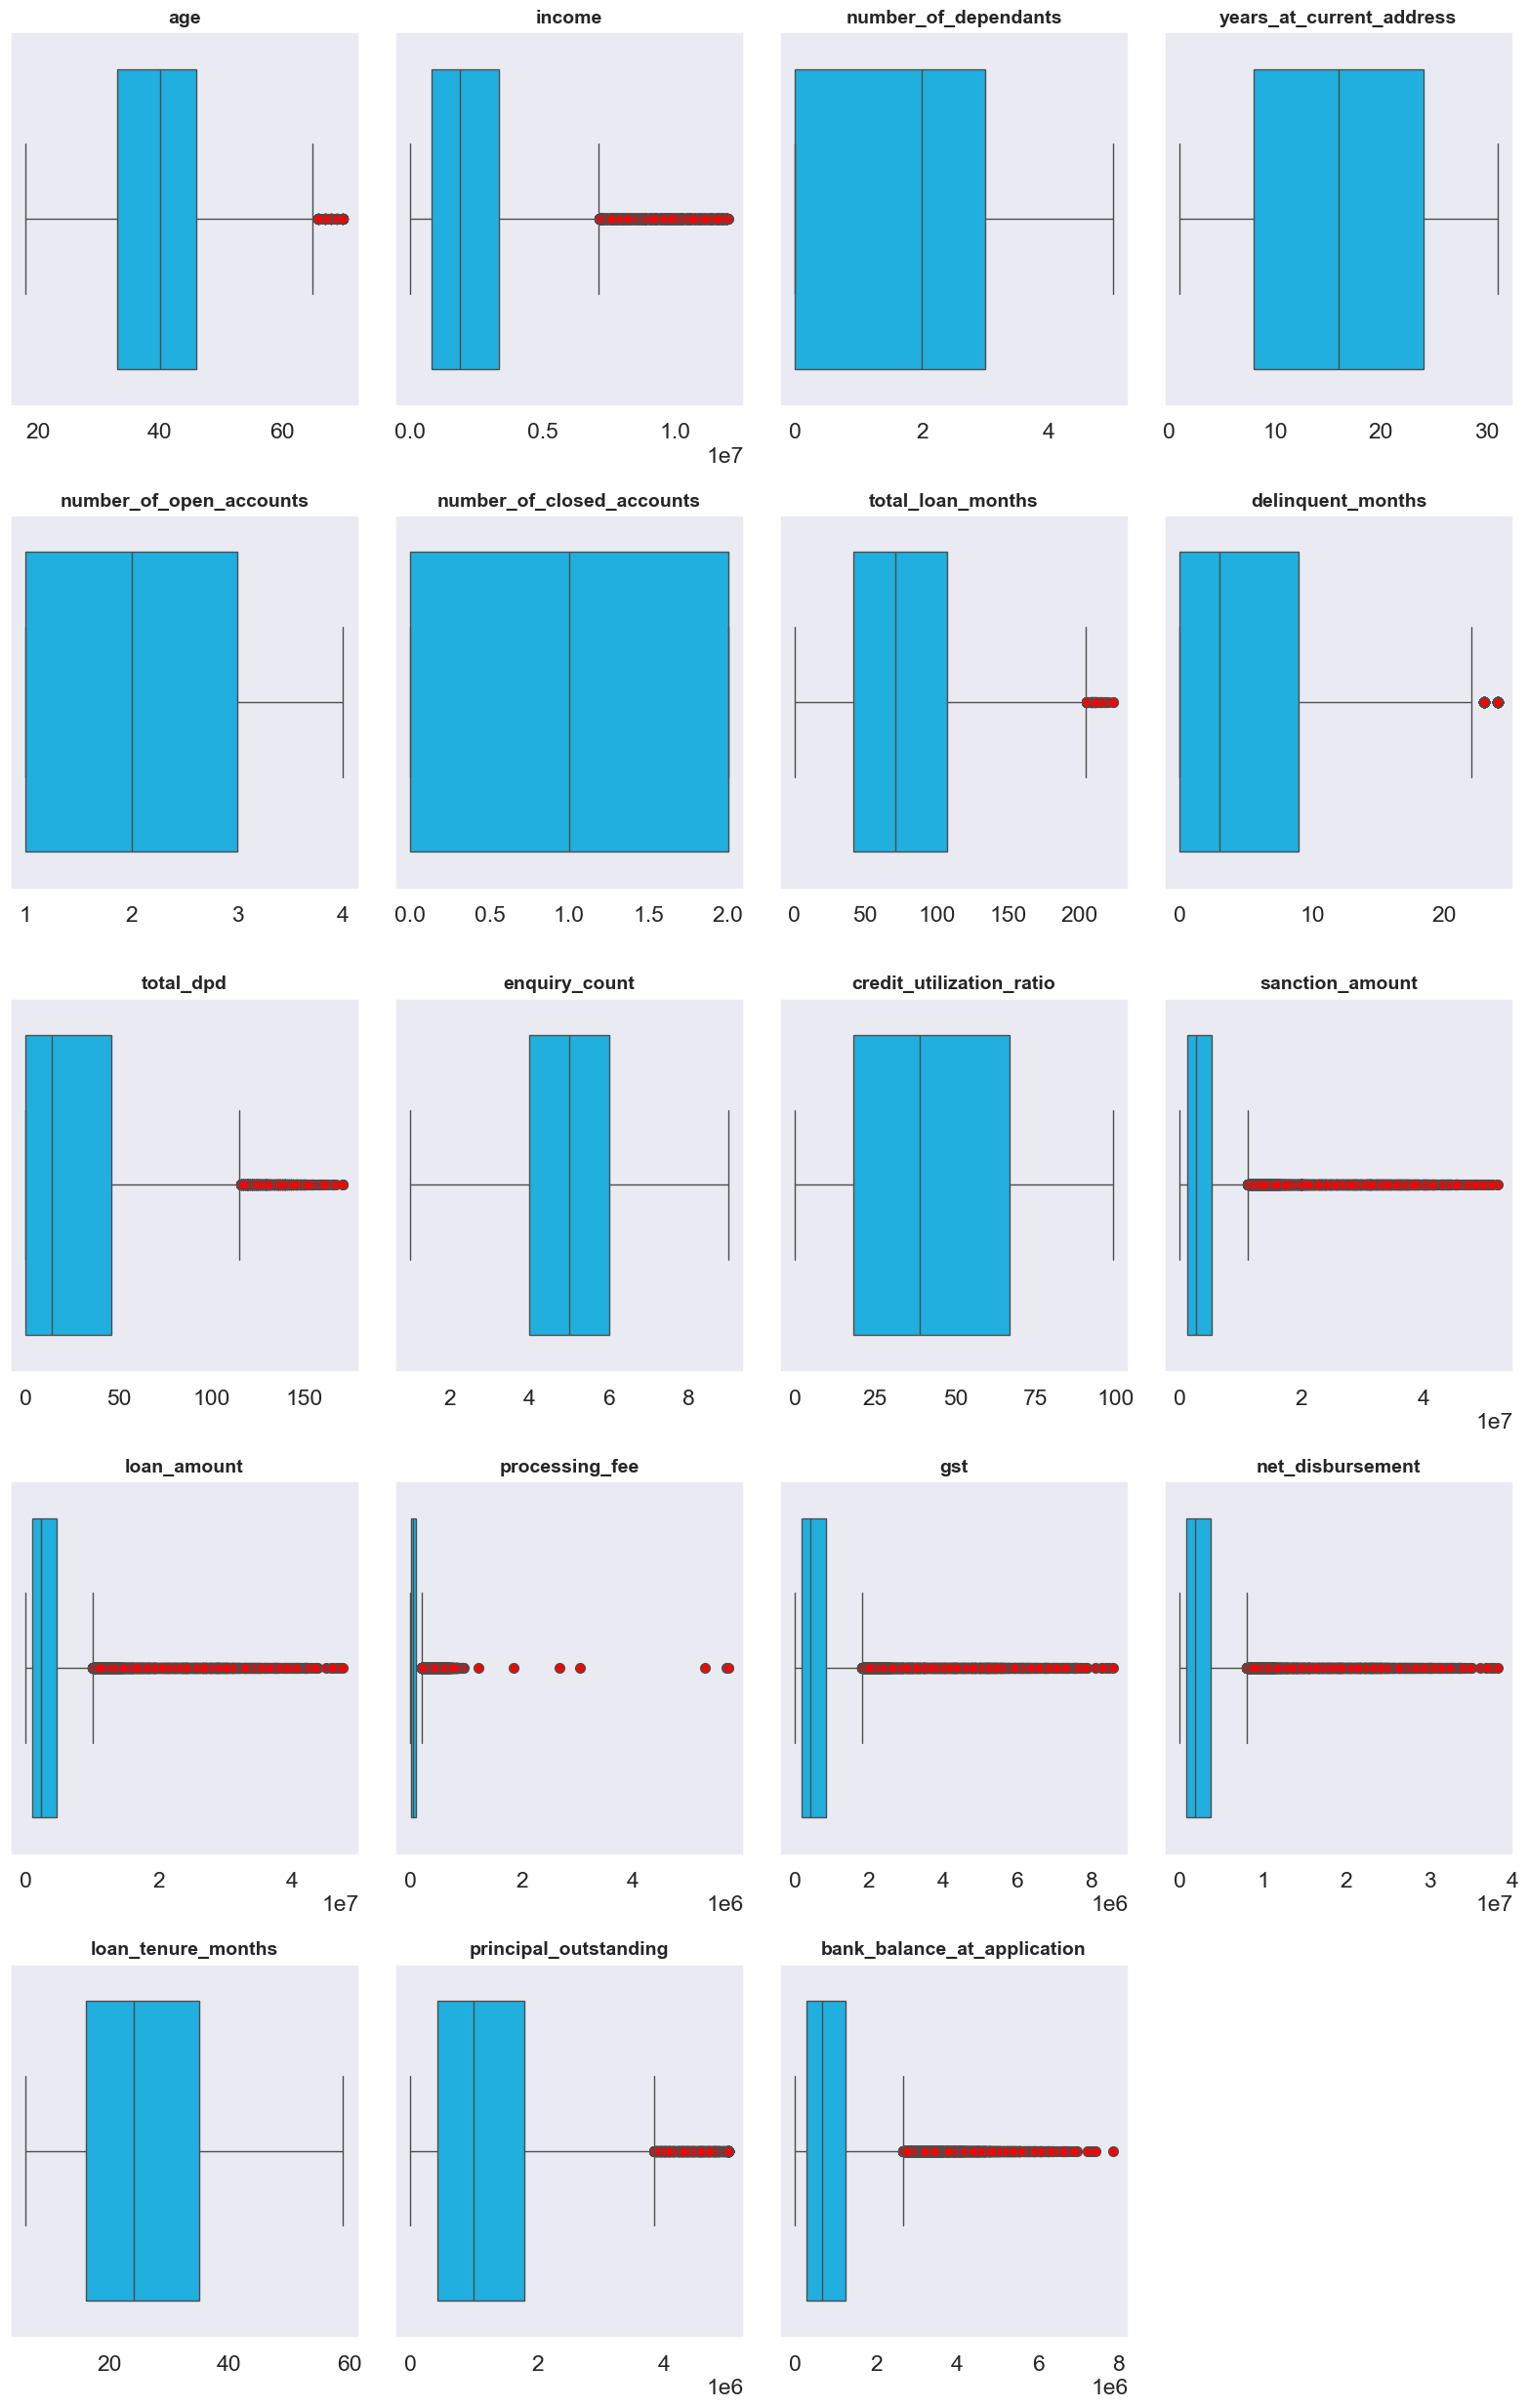

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("dark")
sns.set_context("talk")

cols = continuous_cols
n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        x=x_train[col],
        ax=axes[i],
        color="deepskyblue",
        flierprops={"marker": "o", "markersize": 7, "markerfacecolor": "red"}
    )

    axes[i].set_title(col, fontsize=14, fontweight="bold")
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

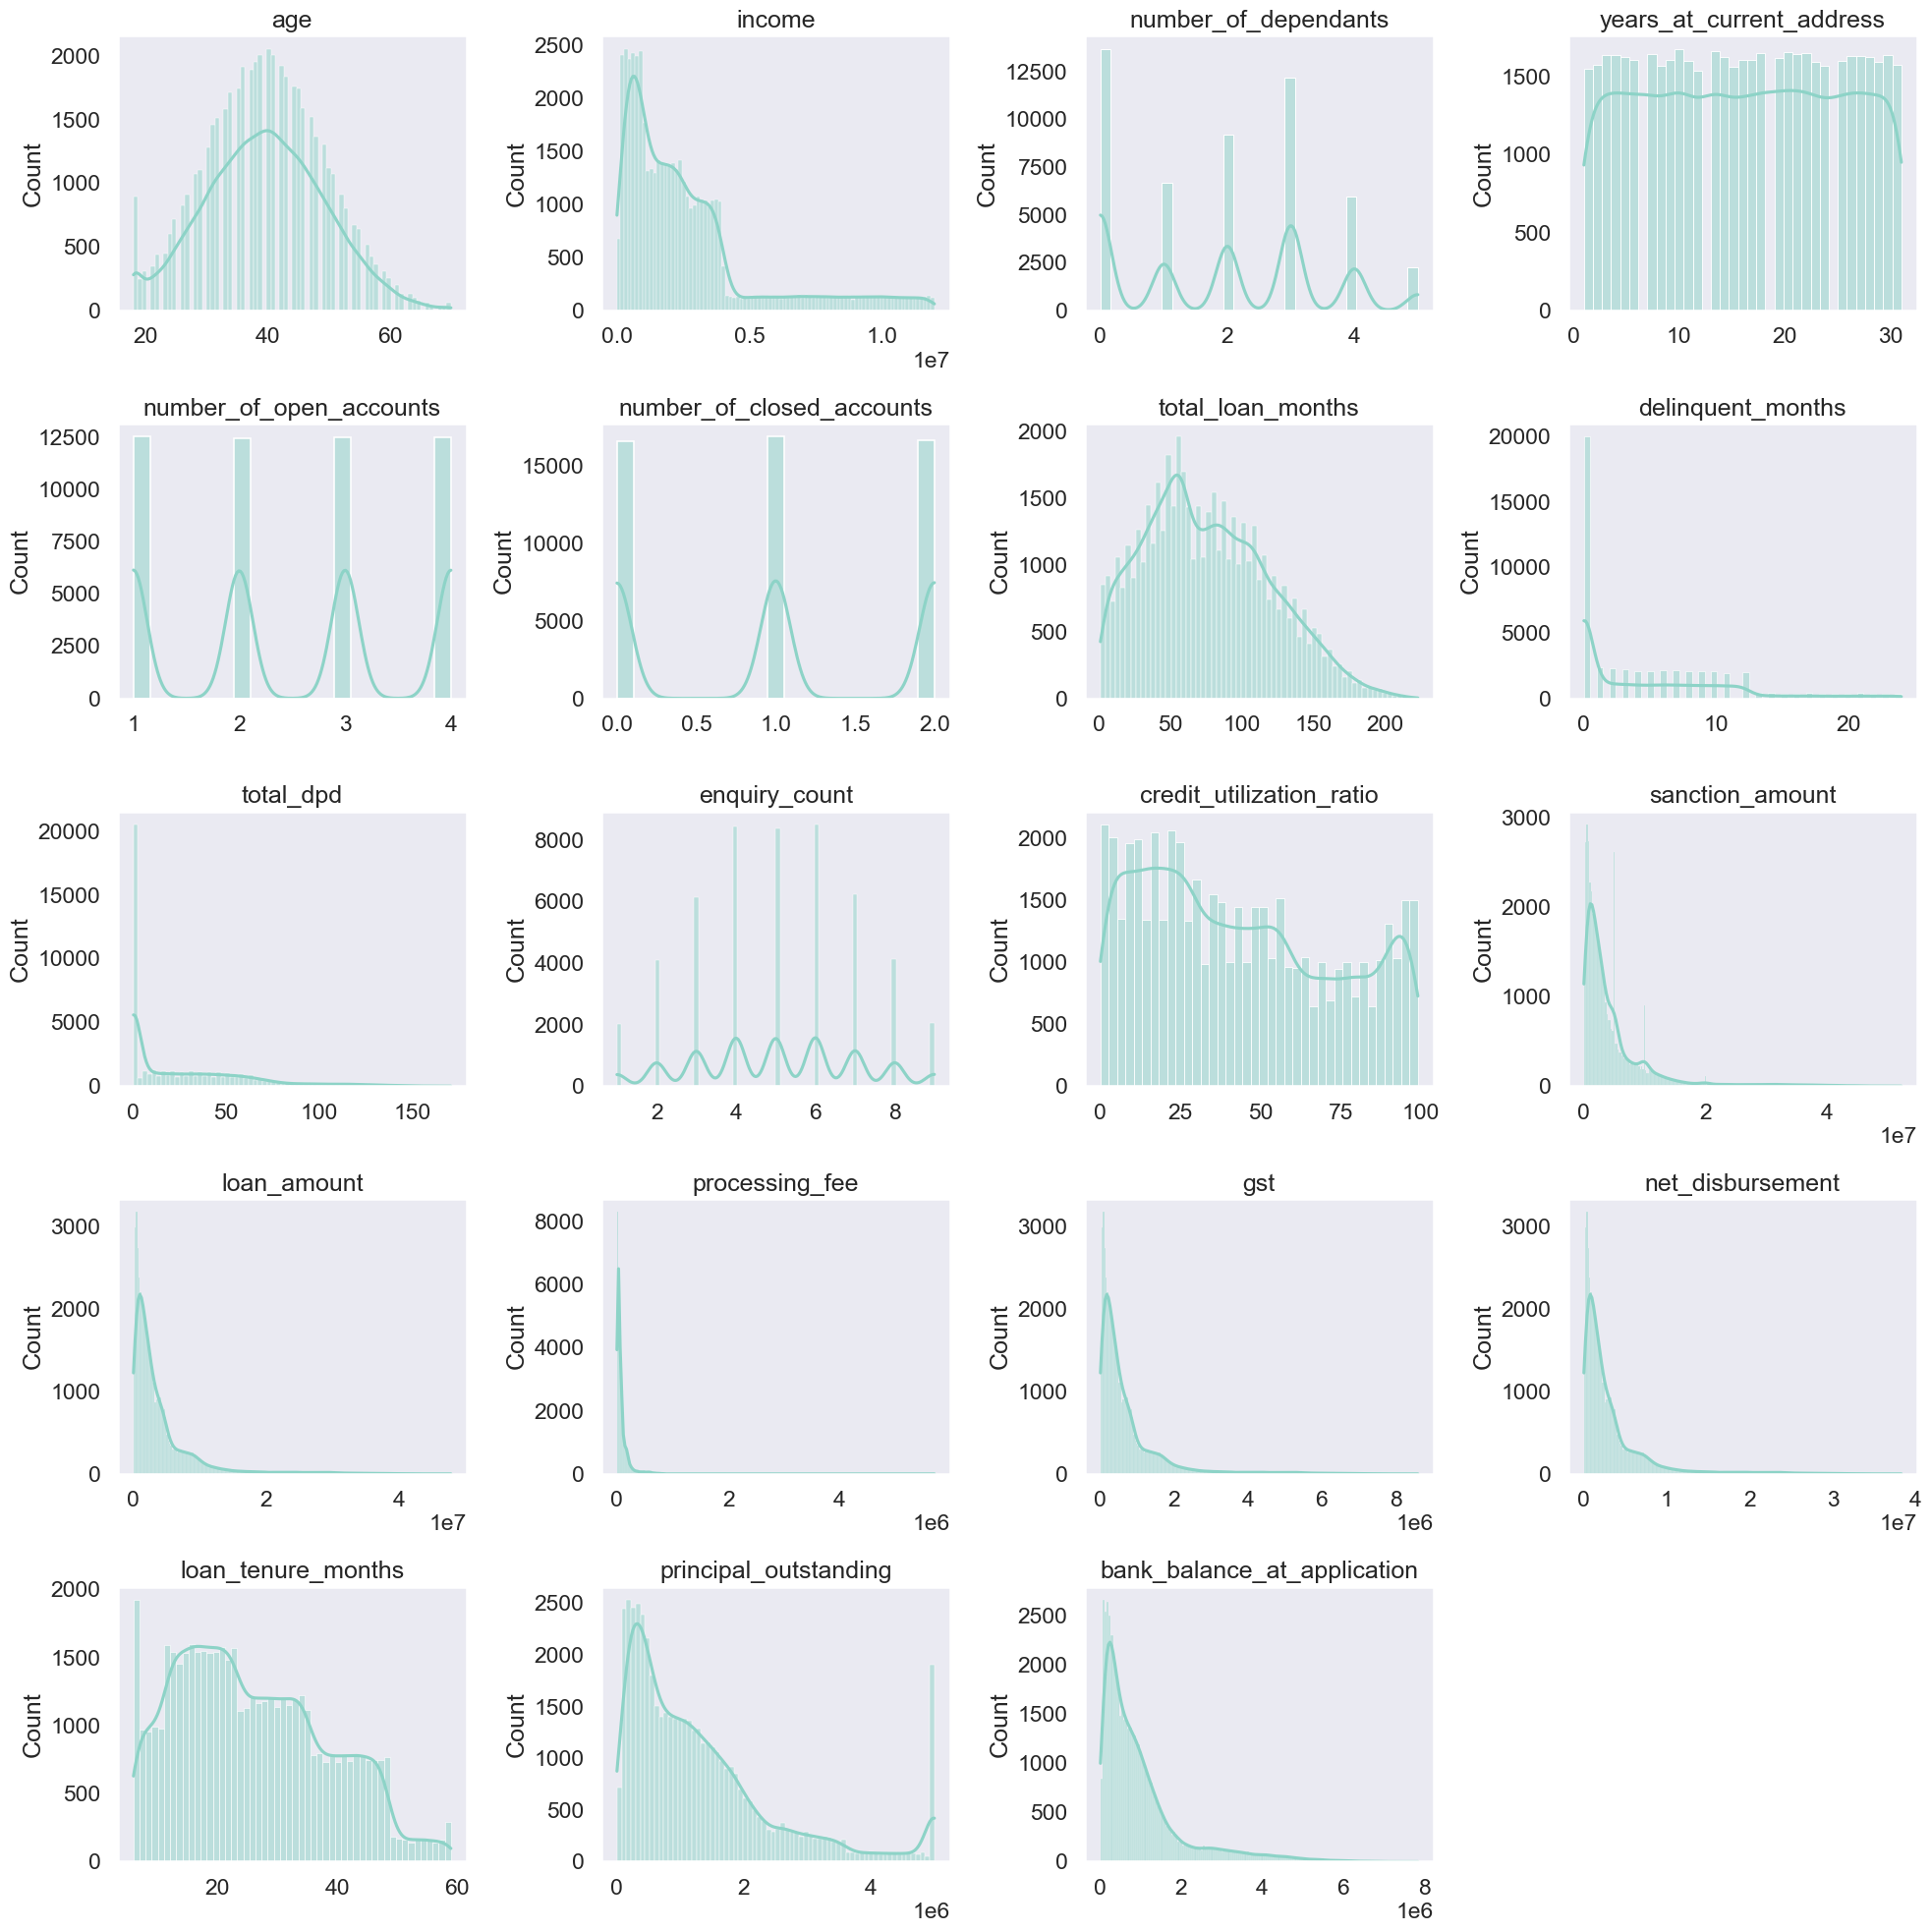

In [75]:
import math
n_cols = 4
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [76]:
df_train['processing_fee'].describe()

count     37500.00
mean      80724.11
std      120830.65
min           0.00
25%       19180.00
50%       44700.00
75%       92000.00
max     5698029.90
Name: processing_fee, dtype: float64

In [77]:
df_train[df_train['processing_fee']==df_train['processing_fee'].max()][['loan_amount','processing_fee']]

,loan_amount,processing_fee
12294,4639000,5698029.90


In [78]:
df_train[df_train['processing_fee']>df_train['loan_amount']][['loan_amount','processing_fee']].shape

(7, 2)

In [79]:
df_train_1=df_train[(df_train['processing_fee']/df_train['loan_amount'])<0.03].copy()
df_train_1.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
27434,C27435,45,F,Single,Salaried,1131000,0,Owned,5,Ahmedabad,...,3276000,65520.00,589680,2620800,24,905176,566117,2022-04-21,2022-05-21,0
13400,C13401,29,M,Single,Salaried,2343000,0,Owned,25,Delhi,...,2540000,50800.00,457200,2032000,33,1008916,951329,2020-11-24,2020-12-11,0
883,C00884,50,F,Single,Self-Employed,2891000,0,Mortgage,29,Lucknow,...,1920000,38400.00,345600,1536000,19,1382399,771873,2019-08-25,2019-09-19,0
7303,C07304,43,F,Single,Self-Employed,272000,1,Owned,27,Bangalore,...,298000,5960.00,53640,238400,21,170015,117343,2020-04-16,2020-05-05,0
45124,C45125,31,F,Single,Salaried,141000,0,Owned,27,Jaipur,...,260000,5200.00,46800,208000,45,72025,67719,2024-01-26,2024-02-17,0


In [80]:
for col in categorical_cols:
    print(col,'---->',df_train_1[col].unique())

gender ----> ['F' 'M']
marital_status ----> ['Single' 'Married']
employment_status ----> ['Salaried' 'Self-Employed']
residence_type ----> ['Owned' 'Mortgage' 'Rented']
city ----> ['Ahmedabad' 'Delhi' 'Lucknow' 'Bangalore' 'Jaipur' 'Hyderabad' 'Kolkata'
 'Pune' 'Chennai' 'Mumbai']
state ----> ['Gujarat' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Rajasthan' 'Telangana'
 'West Bengal' 'Maharashtra' 'Tamil Nadu']
zipcode ----> [380001 110001 226001 560001 302001 500001 700001 411001 600001 400001]
loan_purpose ----> ['Home' 'Auto' 'Personal' 'Education' 'Personaal']
loan_type ----> ['Secured' 'Unsecured']


In [81]:
df_train_1.loc[df_train_1['loan_purpose']=='Personaal','loan_purpose']='Personal'
df_test.loc[df_test['loan_purpose']=='Personaal','loan_purpose']='Personal'

In [82]:
for col in categorical_cols:
    print(col,'---->',df_train_1[col].unique())

gender ----> ['F' 'M']
marital_status ----> ['Single' 'Married']
employment_status ----> ['Salaried' 'Self-Employed']
residence_type ----> ['Owned' 'Mortgage' 'Rented']
city ----> ['Ahmedabad' 'Delhi' 'Lucknow' 'Bangalore' 'Jaipur' 'Hyderabad' 'Kolkata'
 'Pune' 'Chennai' 'Mumbai']
state ----> ['Gujarat' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Rajasthan' 'Telangana'
 'West Bengal' 'Maharashtra' 'Tamil Nadu']
zipcode ----> [380001 110001 226001 560001 302001 500001 700001 411001 600001 400001]
loan_purpose ----> ['Home' 'Auto' 'Personal' 'Education']
loan_type ----> ['Secured' 'Unsecured']


In [83]:
df_train_1[(df_train_1['gst']/df_train_1['loan_amount'])>1]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default


<Axes: xlabel='age', ylabel='Density'>

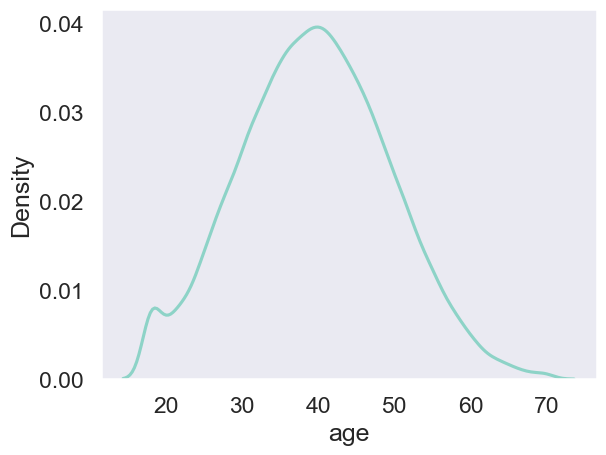

In [84]:
sns.kdeplot(df_train_1['age'])

<Axes: xlabel='age', ylabel='Count'>

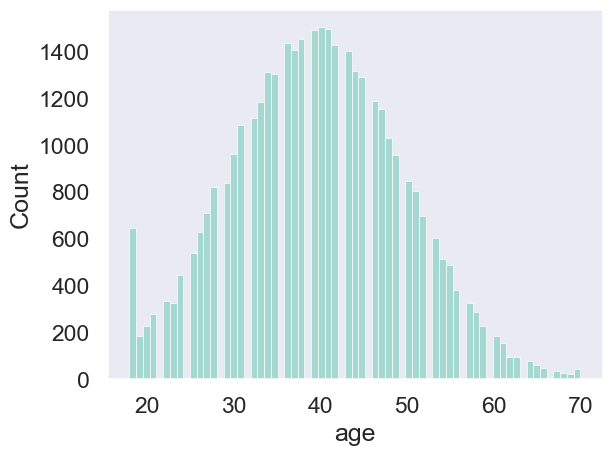

In [85]:
sns.histplot(df_train_1['age'])

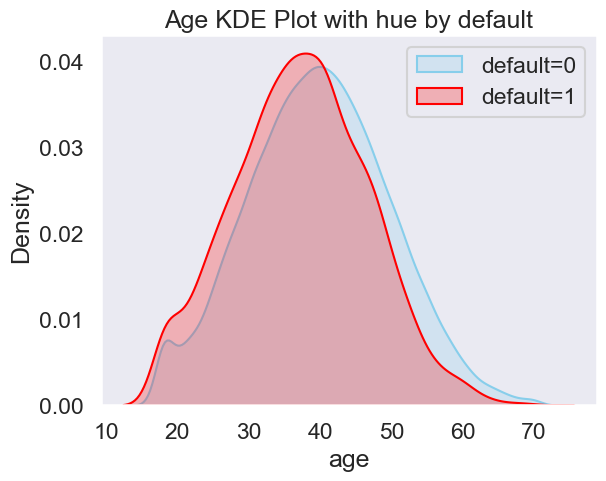

In [86]:
sns.kdeplot(df_train_1[df_train_1['default']==0]['age'],label='default=0',color='skyblue',fill=True)
sns.kdeplot(df_train_1[df_train_1['default']==1]['age'],label='default=1',color='red',fill=True)
plt.title('Age KDE Plot with hue by default')
plt.legend()
plt.show()

Insights
1- Red graph is little bit shifted to left of blue which indicates that the people with young age are more likely to default.

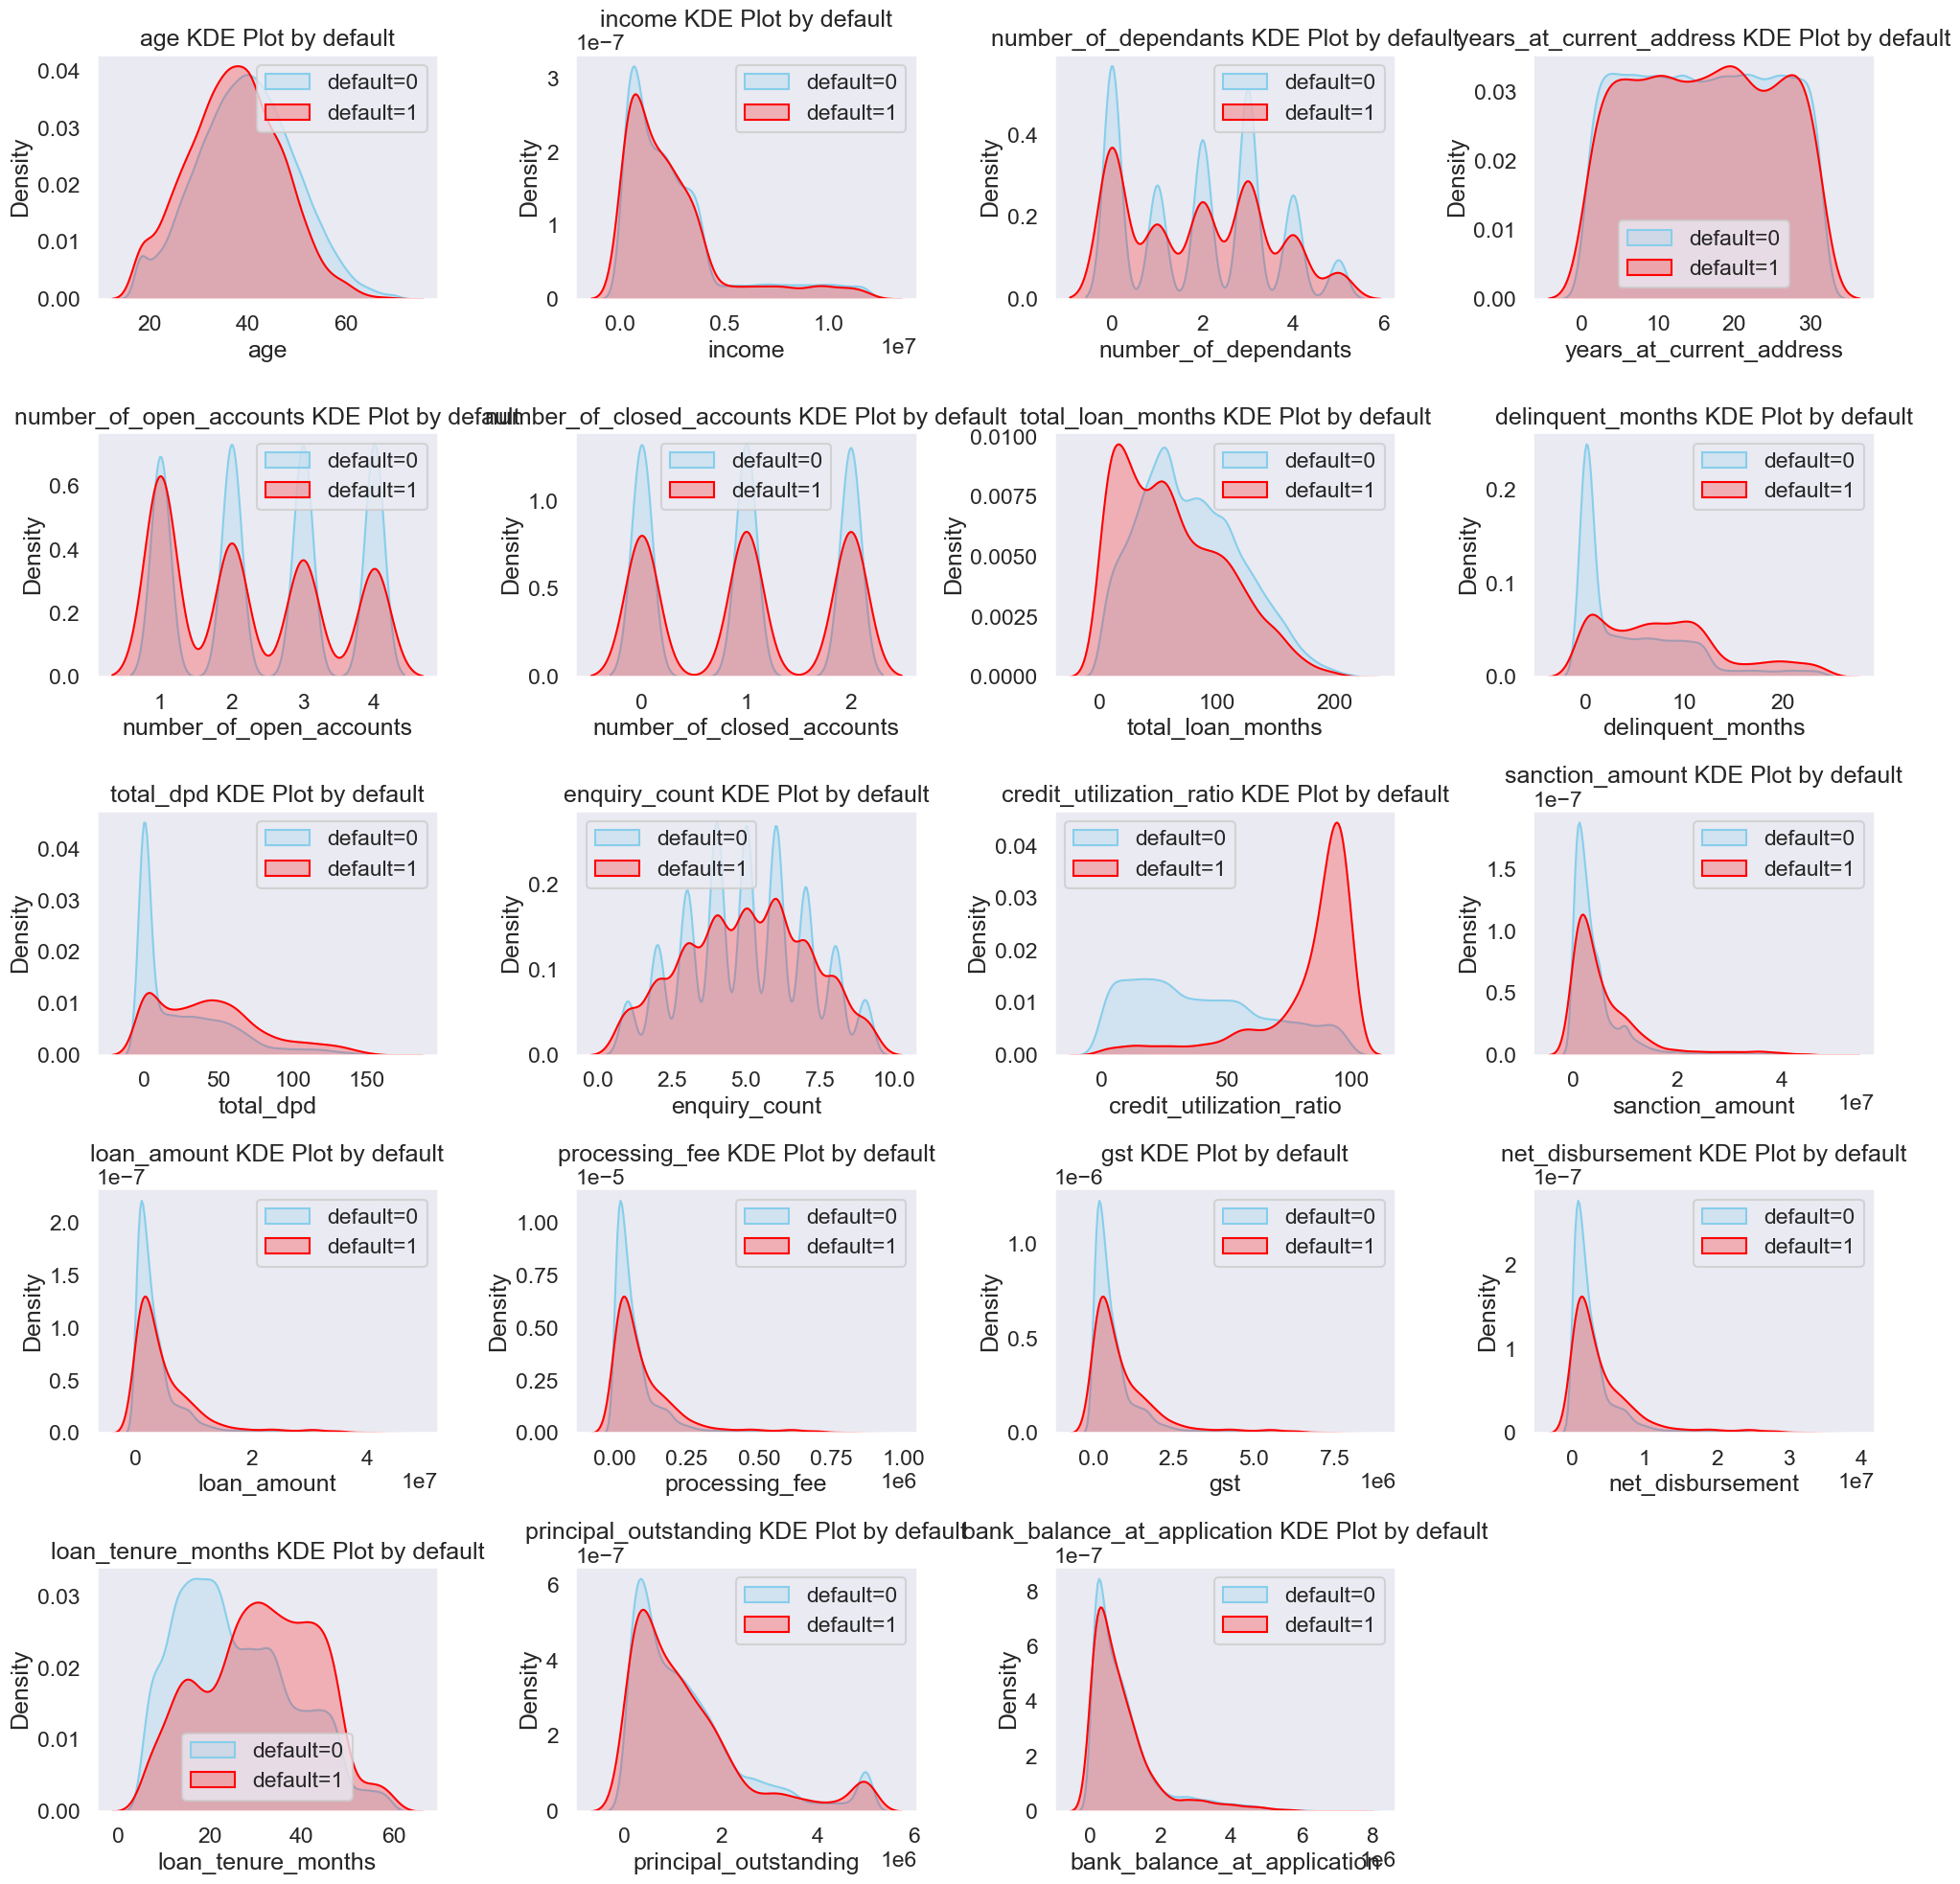

In [87]:
n_cols = 4
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.kdeplot(df_train_1[df_train_1['default']==0][col], label='default=0', color='skyblue', fill=True, ax=axes[i])
    sns.kdeplot(df_train_1[df_train_1['default']==1][col], label='default=1', color='red', fill=True, ax=axes[i])
    axes[i].set_title(f'{col} KDE Plot by default')
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Insights
1- In the columns: loan_tenure_months,deliquent_months,total_dpd,credit_utilization, higher values indicates likelyhood of becoming a default. Hence these 4 looks strong predictors.
2- In remaining columns the distribution do not give any obvious insights.
3- why loan_amount and income did not give any signs of being strong preditors? may be when we combine these two to get loan to income ratio (LTI) that may influence on the target variable.

In [88]:
df_train_1['loan_to_income']=round(df_train_1['loan_amount']/df_train_1['income'],2)
df_test['loan_to_income']=round(df_test['loan_amount']/df_test['income'],2)

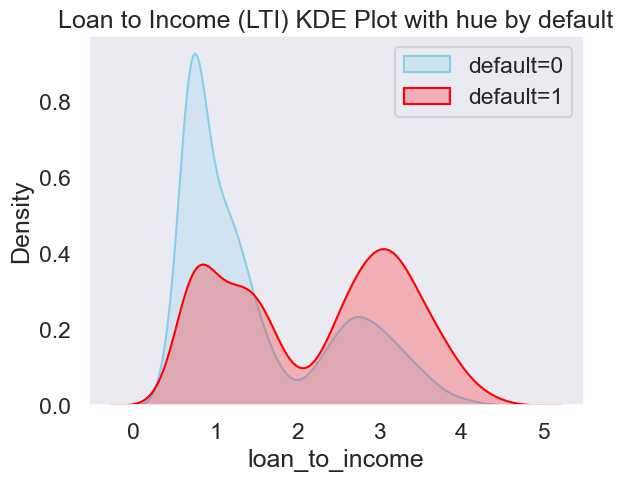

In [89]:
sns.kdeplot(df_train_1[df_train_1['default']==0]['loan_to_income'],label='default=0',color='skyblue',fill=True)
sns.kdeplot(df_train_1[df_train_1['default']==1]['loan_to_income'],label='default=1',color='red',fill=True)
plt.title('Loan to Income (LTI) KDE Plot with hue by default')
plt.legend()
plt.show()

In [91]:
df_train_1['delinquency_ratio'] = (
    df_train_1['delinquent_months'] / df_train_1['total_loan_months']
).replace([np.inf, -np.inf], 0).fillna(0).round(2)
df_test['delinquency_ratio'] = (
    df_test['delinquent_months'] / df_test['total_loan_months']
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

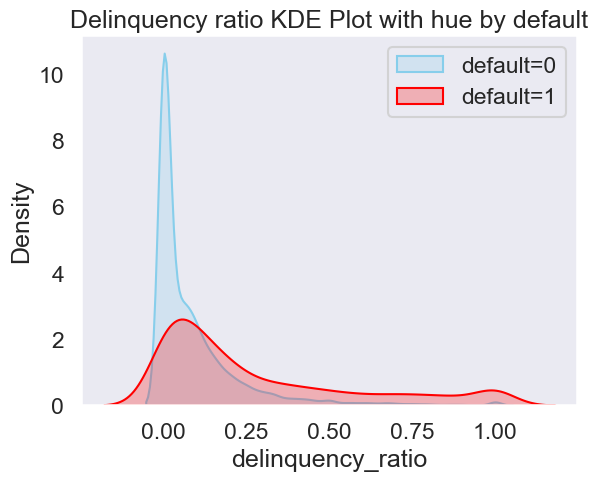

In [92]:
sns.kdeplot(df_train_1[df_train_1['default']==0]['delinquency_ratio'],label='default=0',color='skyblue',fill=True)
sns.kdeplot(df_train_1[df_train_1['default']==1]['delinquency_ratio'],label='default=1',color='red',fill=True)
plt.title('Delinquency ratio KDE Plot with hue by default')
plt.legend()
plt.show()

In [93]:
df_train_1['avg_dpd_per_delinquency']=np.where(
    df_train_1['delinquency_ratio']!=0,
    (df_train_1['total_dpd']/df_train_1['delinquent_months']).round(2),
    0
)
df_test['avg_dpd_per_delinquency']=np.where(
    df_test['delinquency_ratio']!=0,
    (df_test['total_dpd']/df_test['delinquent_months']).round(2),
    0
)

In [94]:
df_train_1.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

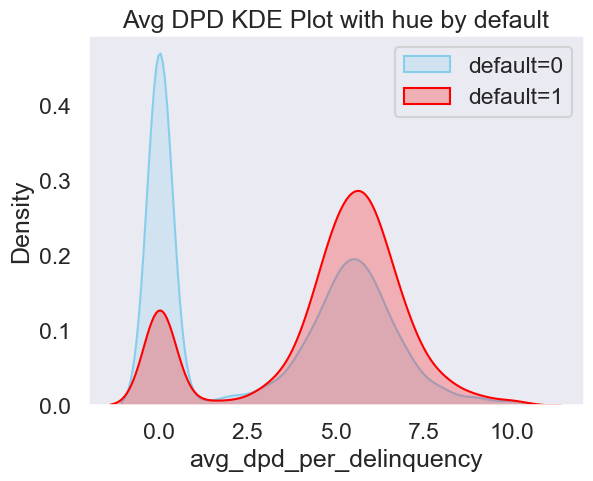

In [95]:
sns.kdeplot(df_train_1[df_train_1['default']==0]['avg_dpd_per_delinquency'],label='default=0',color='skyblue',fill=True)
sns.kdeplot(df_train_1[df_train_1['default']==1]['avg_dpd_per_delinquency'],label='default=1',color='red',fill=True)
plt.title('Avg DPD KDE Plot with hue by default')
plt.legend()
plt.show()

## feature selection

In [96]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_id', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [97]:
df_train_2=df_train_1.drop(['cust_id','loan_id'],axis=1)
df_test=df_test.drop(['cust_id','loan_id'],axis=1)

In [98]:
df_train_3=df_train_2.drop(['disbursal_date','installment_start_dt','loan_amount','income','total_loan_months','total_dpd'],axis=1)
df_test=df_test.drop(['disbursal_date','installment_start_dt','loan_amount','income','total_loan_months','total_dpd'],axis=1)

In [99]:
df_train_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37487 entries, 27434 to 15795
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37487 non-null  int64  
 1   gender                       37487 non-null  object 
 2   marital_status               37487 non-null  object 
 3   employment_status            37487 non-null  object 
 4   number_of_dependants         37487 non-null  int64  
 5   residence_type               37487 non-null  object 
 6   years_at_current_address     37487 non-null  int64  
 7   city                         37487 non-null  object 
 8   state                        37487 non-null  object 
 9   zipcode                      37487 non-null  int64  
 10  number_of_open_accounts      37487 non-null  int64  
 11  number_of_closed_accounts    37487 non-null  int64  
 12  delinquent_months            37487 non-null  int64  
 13  enquiry_count    

In [100]:
cols_to_scale=df_train_3.select_dtypes(['int64','float64']).columns.drop(['zipcode','default'])
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'delinquent_months', 'enquiry_count', 'credit_utilization_ratio',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [101]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
x_train=df_train_3.drop(['default'],axis=1)
y_train=df_train_3['default']
scalar=MinMaxScaler()
x_train[cols_to_scale]=scalar.fit_transform(x_train[cols_to_scale])
x_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,delinquent_months,enquiry_count,credit_utilization_ratio,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00
mean,0.41,0.39,0.50,418763.45,0.50,0.50,0.20,0.50,0.44,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.29,0.10,0.33
std,0.19,0.31,0.30,168837.51,0.37,0.41,0.24,0.25,0.30,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.23,0.17,0.29
min,0.00,0.00,0.00,110001.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,302001.00,0.00,0.00,0.00,0.38,0.18,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.11,0.00,0.00
50%,0.42,0.40,0.50,400001.00,0.33,0.50,0.12,0.50,0.39,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.20,0.04,0.43
75%,0.54,0.60,0.77,560001.00,0.67,1.00,0.38,0.62,0.68,0.10,0.10,0.10,0.10,0.55,0.35,0.16,0.50,0.13,0.58
max,1.00,1.00,1.00,700001.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [102]:
x_test=df_test.drop(['default'],axis=1)
y_test=df_test['default']
x_test[cols_to_scale]=scalar.transform(x_test[cols_to_scale])

In [103]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df['feature']=data.columns
    vif_df['vif']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [104]:
calculate_vif(x_train[cols_to_scale])

C:\Users\ayush\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,vif
0,age,5.59
1,number_of_dependants,2.72
2,years_at_current_address,3.36
3,number_of_open_accounts,4.51
4,number_of_closed_accounts,2.34
5,delinquent_months,3.53
6,enquiry_count,6.32
7,credit_utilization_ratio,2.89
8,sanction_amount,102.16
9,processing_fee,inf


In [105]:
features_to_drop=['sanction_amount','principal_outstanding','processing_fee','gst','net_disbursement']
x_train=x_train.drop(features_to_drop,axis=1)
numeric_col=x_train.select_dtypes(["int64","float64"]).columns.drop(['zipcode'])
numeric_col

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'delinquent_months', 'enquiry_count', 'credit_utilization_ratio',
       'loan_tenure_months', 'bank_balance_at_application', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [106]:
vif_df=calculate_vif(x_train[numeric_col])
vif_df

,feature,vif
0,age,5.30
1,number_of_dependants,2.72
2,years_at_current_address,3.34
3,number_of_open_accounts,4.48
4,number_of_closed_accounts,2.33
5,delinquent_months,3.53
6,enquiry_count,6.28
7,credit_utilization_ratio,2.88
8,loan_tenure_months,5.97
9,bank_balance_at_application,1.79


In [107]:
selected_numeric_feature_vif=vif_df.feature.values
selected_numeric_feature_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'delinquent_months', 'enquiry_count', 'credit_utilization_ratio',
       'loan_tenure_months', 'bank_balance_at_application',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype=object)

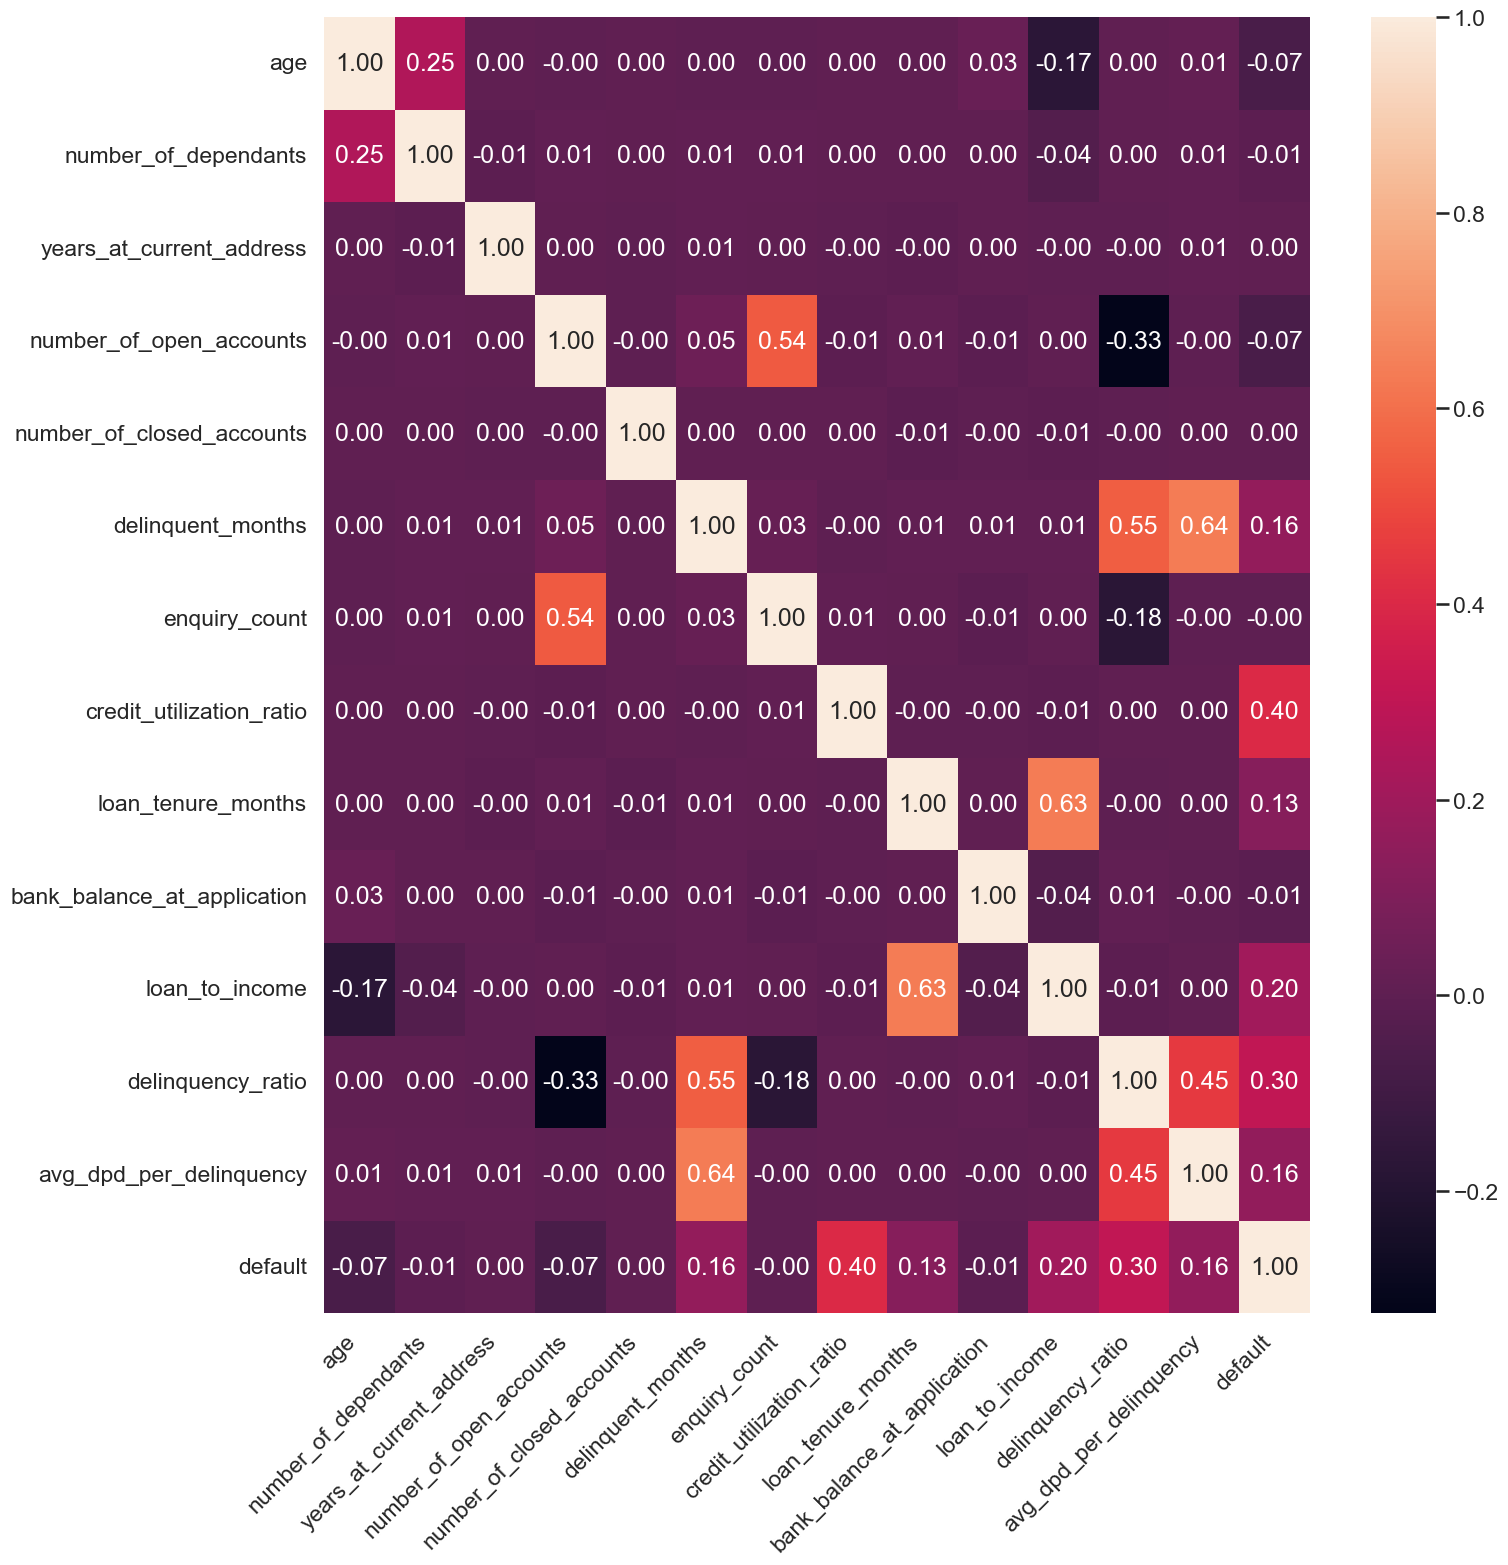

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16,16))
cm=df_train_3[numeric_col.tolist() + ['default']].corr()
sns.heatmap(cm,annot=True,fmt='0.2f')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [109]:
x_train.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'number_of_open_accounts',
       'number_of_closed_accounts', 'delinquent_months', 'enquiry_count',
       'credit_utilization_ratio', 'loan_purpose', 'loan_type',
       'loan_tenure_months', 'bank_balance_at_application', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [110]:
temp=pd.concat([x_train,y_train],axis=1)
temp.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,enquiry_count,credit_utilization_ratio,loan_purpose,loan_type,loan_tenure_months,bank_balance_at_application,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,default
27434,0.52,F,Single,Salaried,0.00,Owned,0.13,Ahmedabad,Gujarat,380001,...,0.88,0.60,Home,Secured,0.34,0.07,0.61,0.07,0.55,0
13400,0.21,M,Single,Salaried,0.00,Owned,0.80,Delhi,Delhi,110001,...,0.38,0.93,Auto,Secured,0.51,0.12,0.18,0.03,0.43,0
883,0.62,F,Single,Self-Employed,0.00,Mortgage,0.93,Lucknow,Uttar Pradesh,226001,...,0.38,0.84,Personal,Unsecured,0.25,0.10,0.08,0.17,0.56,0
7303,0.48,F,Single,Self-Employed,0.20,Owned,0.87,Bangalore,Karnataka,560001,...,0.50,0.34,Auto,Secured,0.28,0.01,0.19,0.00,0.00,0
45124,0.25,F,Single,Salaried,0.00,Owned,0.87,Jaipur,Rajasthan,302001,...,0.50,0.19,Education,Secured,0.74,0.01,0.36,0.10,0.47,0


In [111]:
def calculate_wor_iv(df,feature,target):
    grouped=df.groupby(feature)[target].agg(['count','sum'])
    grouped.rename(columns={'count':'total','sum':'bad'},inplace=True)
    grouped['good']=grouped['total']-grouped['bad']
    total_good=grouped['good'].sum()
    total_bad=grouped['bad'].sum()
    grouped['good_pct']=grouped['good']/total_good
    grouped['bad_pct']=grouped['bad']/total_bad
    grouped['woe']=np.log(grouped['good_pct']/grouped['bad_pct'])
    grouped['iv']=grouped['woe']*(grouped['good_pct']-grouped['bad_pct'])

    grouped['woe'].replace([np.inf,-np.inf],0,inplace=True)
    grouped['iv'].replace([np.inf,-np.inf],0,inplace=True)
    total_iv=grouped['iv'].sum()
    return grouped,total_iv
grouped,total_iv=calculate_wor_iv(temp,'loan_purpose','default')
grouped,total_iv

(              total   bad   good  good_pct  bad_pct   woe   iv
 loan_purpose                                                  
 Auto           7437   314   7123      0.21     0.10  0.75 0.08
 Education      5626   546   5080      0.15     0.17 -0.14 0.00
 Home          11271  1744   9527      0.28     0.55 -0.68 0.18
 Personal      13153   585  12568      0.37     0.18  0.69 0.13,
 np.float64(0.39377543144164784))

In [112]:
iv_values={}
for feature in x_train.columns:
    if x_train[feature].dtype=='object':
        _,iv=calculate_wor_iv(pd.concat([x_train,y_train],axis=1),feature,'default')
        iv_values[feature]=iv
    else:
        x_binned=pd.cut(x_train[feature],bins=10,labels=False)
        _,iv=calculate_wor_iv(pd.concat([x_binned,y_train],axis=1),feature,'default')
        iv_values[feature]=iv
iv_values

{'age': np.float64(0.07592687127752061),
 'gender': np.float64(0.0004822764634212165),
 'marital_status': np.float64(0.00219668137083232),
 'employment_status': np.float64(0.002447818101774484),
 'number_of_dependants': np.float64(0.0036458945211859596),
 'residence_type': np.float64(0.25940196175639846),
 'years_at_current_address': np.float64(0.0010425363803530285),
 'city': np.float64(0.0008178704653341025),
 'state': np.float64(0.0007881984519711978),
 'zipcode': np.float64(0.0007436024782513755),
 'number_of_open_accounts': np.float64(0.07324250836253293),
 'number_of_closed_accounts': np.float64(0.0002628082402176055),
 'delinquent_months': np.float64(0.36077782012105086),
 'enquiry_count': np.float64(0.00548498263830353),
 'credit_utilization_ratio': np.float64(2.4228228499400095),
 'loan_purpose': np.float64(0.39377543144164784),
 'loan_type': np.float64(0.17304705897793143),
 'loan_tenure_months': np.float64(0.23450610202970526),
 'bank_balance_at_application': np.float64(0.00

In [113]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
iv_df=pd.DataFrame(iv_values.items(),columns=['feature','iv']).sort_values('iv',ascending=False)
iv_df

,feature,iv
14,credit_utilization_ratio,2.423
20,delinquency_ratio,0.678
19,loan_to_income,0.492
21,avg_dpd_per_delinquency,0.421
15,loan_purpose,0.394
12,delinquent_months,0.361
5,residence_type,0.259
17,loan_tenure_months,0.235
16,loan_type,0.173
0,age,0.076


In [114]:
selected_features=iv_df[iv_df['iv']>0.02]['feature'].tolist()
selected_features

['credit_utilization_ratio',
 'delinquency_ratio',
 'loan_to_income',
 'avg_dpd_per_delinquency',
 'loan_purpose',
 'delinquent_months',
 'residence_type',
 'loan_tenure_months',
 'loan_type',
 'age',
 'number_of_open_accounts']

In [115]:
x_train_reduced=x_train[selected_features]
x_test_reduced=x_test[selected_features]

In [116]:
x_train_reduced.head()

,credit_utilization_ratio,delinquency_ratio,loan_to_income,avg_dpd_per_delinquency,loan_purpose,delinquent_months,residence_type,loan_tenure_months,loan_type,age,number_of_open_accounts
27434,0.596,0.070,0.609,0.550,Home,0.250,Owned,0.340,Secured,0.519,1.000
13400,0.929,0.030,0.183,0.425,Auto,0.167,Owned,0.509,Secured,0.212,0.667
883,0.838,0.170,0.084,0.557,Personal,0.583,Mortgage,0.245,Unsecured,0.615,0.333
7303,0.343,0.000,0.187,0.000,Auto,0.000,Owned,0.283,Secured,0.481,0.000
45124,0.192,0.100,0.361,0.467,Education,0.250,Owned,0.736,Secured,0.250,0.333


In [117]:
x_train_reduced=pd.get_dummies(x_train_reduced,drop_first=True)
x_test_reduced=pd.get_dummies(x_test_reduced,drop_first=True)
x_test_reduced.head()

,credit_utilization_ratio,delinquency_ratio,loan_to_income,avg_dpd_per_delinquency,delinquent_months,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
33553,0.121,0.040,0.258,0.900,0.125,0.528,0.346,0.333,True,False,False,True,False,False
9427,0.859,0.000,0.689,0.000,0.000,0.623,0.288,1.000,False,True,False,True,False,False
199,0.727,0.000,0.635,0.000,0.000,0.623,0.192,1.000,False,True,False,True,False,False
12447,0.909,0.000,0.187,0.000,0.000,0.189,0.192,0.667,False,False,False,False,True,False
39489,0.535,0.130,0.169,0.525,0.833,0.377,0.654,1.000,False,False,False,True,False,False


In [118]:
x_test_reduced.head()

,credit_utilization_ratio,delinquency_ratio,loan_to_income,avg_dpd_per_delinquency,delinquent_months,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
33553,0.121,0.040,0.258,0.900,0.125,0.528,0.346,0.333,True,False,False,True,False,False
9427,0.859,0.000,0.689,0.000,0.000,0.623,0.288,1.000,False,True,False,True,False,False
199,0.727,0.000,0.635,0.000,0.000,0.623,0.192,1.000,False,True,False,True,False,False
12447,0.909,0.000,0.187,0.000,0.000,0.189,0.192,0.667,False,False,False,False,True,False
39489,0.535,0.130,0.169,0.525,0.833,0.377,0.654,1.000,False,False,False,True,False,False


In [119]:
x_train_reduced.shape,x_test_reduced.shape

((37487, 14), (12500, 14))

In [120]:
x_test_reduced = x_test_reduced.dropna()
y_test = y_test.loc[x_test_reduced.index]

## Model Training

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
model=LogisticRegression()
model.fit(x_train_reduced,y_train)
y_pred=model.predict(x_test_reduced)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.69      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
model=RandomForestClassifier()
model.fit(x_train_reduced,y_train)
y_pred=model.predict(x_test_reduced)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.86      0.70      0.77      1108

    accuracy                           0.96     12498
   macro avg       0.91      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [123]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
model=XGBClassifier()
model.fit(x_train_reduced,y_train)
y_pred=model.predict(x_test_reduced)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     11390
           1       0.82      0.73      0.78      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.86      0.88     12498
weighted avg       0.96      0.96      0.96     12498



In [124]:
# from sklearn.model_selection import RandomizedSearchCV
# param_dist={
#     'C': np.logspace(-4,4,20),
#     'solver': ['lbfgs','saga','liblinear','newton-cg']
# }
# log_reg=LogisticRegression(max_iter=10000, class_weight='balanced')
#
# random_search=RandomizedSearchCV(
#     estimator=log_reg,
#     param_distributions=param_dist,
#     n_iter=80,
#     cv=3,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1,
#     scoring='f1'
# )
# random_search.fit(x_train_reduced,y_train)
# print(f'best params: {random_search.best_params_}')
# print(f'best score: {random_search.best_score_}')
#
# best_model=random_search.best_estimator_
# y_pred=best_model.predict(x_test_reduced)
# print(classification_report(y_test,y_pred))

In [125]:
# from xgboost import XGBClassifier
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import classification_report
# import numpy as np
#
# # Model
# xgb = XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='logloss',
#     use_label_encoder=False
# )
#
# # Hyperparameter space
# param_dist = {
#     'n_estimators': [100, 200,250, 300, 500],
#     'max_depth': [3, 4, 5, 6, 8],
#     'learning_rate': [0.01,0.03, 0.05, 0.1,0.15, 0.2,0.25,0.3],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'gamma': [0, 0.1, 0.2, 0.3],
#     'reg_alpha': [0.01,0.1,0.5, 1.0,5.0,10.0],
#     'reg_lambda': [0.01,0.1,0.5, 1.0,5.0,10.0]
# }
#
# random_search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_dist,
#     n_iter=100,
#     cv=3,
#     scoring='f1',
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )
#
#
# random_search.fit(x_train_reduced, y_train)
#
# print("Best Params:", random_search.best_params_)
# print("Best CV Recall:", random_search.best_score_)
#
# # Best model
# best_model = random_search.best_estimator_
#
#
# y_pred = best_model.predict(x_test_reduced)
#
#
# print(classification_report(y_test, y_pred))

In [126]:
from imblearn.under_sampling import RandomUnderSampler

smote = RandomUnderSampler(random_state=42)

x_train_balanced, y_train_balanced = smote.fit_resample(x_train_reduced, y_train)

print(y_train.value_counts())          # before
print(y_train_balanced.value_counts())

default
0    34298
1     3189
Name: count, dtype: int64
default
0    3189
1    3189
Name: count, dtype: int64


In [127]:
# from sklearn.model_selection import RandomizedSearchCV
# param_dist={
#     'C': np.logspace(-4,4,20),
#     'solver': ['lbfgs','saga','liblinear','newton-cg']
# }
# log_reg=LogisticRegression(max_iter=10000, class_weight='balanced')
#
# random_search=RandomizedSearchCV(
#     estimator=log_reg,
#     param_distributions=param_dist,
#     n_iter=80,
#     cv=3,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1,
#     scoring='f1'
# )
# random_search.fit(x_train_balanced,y_train_balanced)
# print(f'best params: {random_search.best_params_}')
# print(f'best score: {random_search.best_score_}')
#
# best_model=random_search.best_estimator_
# y_pred=best_model.predict(x_test_reduced)
# print(classification_report(y_test,y_pred))

In [128]:
model=LogisticRegression()
model.fit(x_train_balanced,y_train_balanced)
y_pred=model.predict(x_test_reduced)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11390
           1       0.53      0.95      0.68      1108

    accuracy                           0.92     12498
   macro avg       0.76      0.93      0.82     12498
weighted avg       0.95      0.92      0.93     12498



In [129]:
model=XGBClassifier()
model.fit(x_train_balanced,y_train_balanced)
y_pred=model.predict(x_test_reduced)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     11390
           1       0.58      0.95      0.72      1108

    accuracy                           0.93     12498
   macro avg       0.79      0.94      0.84     12498
weighted avg       0.96      0.93      0.94     12498



In [130]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smt, y_train_smt = smote.fit_resample(x_train_reduced, y_train)
print("Before:", y_train.value_counts())
print("After:", y_train_balanced.value_counts())

Before: default
0    34298
1     3189
Name: count, dtype: int64
After: default
0    3189
1    3189
Name: count, dtype: int64


In [131]:
model=XGBClassifier()
model.fit(x_train_smt,y_train_smt)
y_pred=model.predict(x_test_reduced)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11390
           1       0.76      0.81      0.78      1108

    accuracy                           0.96     12498
   macro avg       0.87      0.89      0.88     12498
weighted avg       0.96      0.96      0.96     12498



In [132]:
model=LogisticRegression()
model.fit(x_train_smt,y_train_smt)
y_pred=model.predict(x_test_reduced)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.84     12498
weighted avg       0.96      0.93      0.94     12498



In [133]:
import optuna
from sklearn.model_selection import cross_val_score

In [134]:

# def objective(trial):
#     c=trial.suggest_float('C', 1,5)
#     solver=trial.suggest_categorical('solver',['lbfgs','sag','saga','liblinear','newton-cg'])
#     model=LogisticRegression(C=c,solver=solver,max_iter=1000)
#     scores=cross_val_score(model,x_train_smt,y_train_smt,cv=3,scoring='accuracy')
#     accuracy=np.mean(scores)
#     return accuracy
# study=optuna.create_study(direction='maximize')
# study.optimize(objective,n_trials=50)
# print(f'print parameters: ',study.best_params)
# print(f'best cross-validation accuracy: ',study.best_value)

In [135]:
model=LogisticRegression(C= 4.990805300171644,solver='lbfgs',max_iter=1000)
model.fit(x_train_smt,y_train_smt)
y_pred=model.predict(x_test_reduced)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.84     12498
weighted avg       0.96      0.93      0.94     12498



In [136]:
# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 0, 5),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
#         'use_label_encoder': False,
#         'eval_metric': 'logloss'
#     }
#
#     model = XGBClassifier(**params)
#
#     scores = cross_val_score(
#         model,
#         x_train_smt,
#         y_train_smt,
#         cv=3,
#         scoring='accuracy'
#     )
#
#     return np.mean(scores)
#
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
#
# print("Best parameters:", study.best_params)
# print("Best CV accuracy:", study.best_value)

In [137]:
model=XGBClassifier(n_estimators= 285, max_depth= 9, learning_rate= 0.05630959528902746, subsample= 0.6502337753651646, colsample_bytree= 0.6353064463665146, gamma= 0.30892955582596693, reg_alpha= 0.3890185573721838, reg_lambda=0.6557147222351776)
model.fit(x_train_smt,y_train_smt)
y_pred=model.predict(x_test_reduced)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11390
           1       0.76      0.82      0.79      1108

    accuracy                           0.96     12498
   macro avg       0.87      0.90      0.88     12498
weighted avg       0.96      0.96      0.96     12498



# Best model

In [138]:
model=LogisticRegression(C= 4.990805300171644,solver='lbfgs',max_iter=1000)
model.fit(x_train_smt,y_train_smt)
y_pred=model.predict(x_test_reduced)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.84     12498
weighted avg       0.96      0.93      0.94     12498



In [139]:
from sklearn.metrics import roc_curve,auc
probabilities=model.predict_proba(x_test_reduced)[:,1]
fpr, tpr, thresholds=roc_curve(y_test,probabilities)
area=auc(fpr,tpr)
fpr[:5],tpr[:5],thresholds[:5],area

(array([0.       , 0.       , 0.       , 0.0000878, 0.0000878]),
 array([0.        , 0.00090253, 0.19404332, 0.19404332, 0.22382671]),
 array([       inf, 0.99999995, 0.99893273, 0.99892773, 0.99853488]),
 0.9830905728313202)

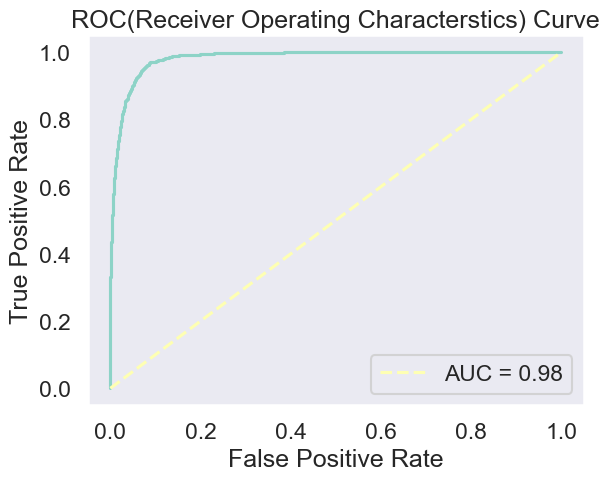

In [140]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--',label='AUC = %0.2f' % area)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC(Receiver Operating Characterstics) Curve')
plt.legend(loc="lower right")
plt.show()

## Model Evaluation: Rank Order and KS Statistics

In [141]:
df=pd.DataFrame({
    'default truth':y_test,
    'default prediction':probabilities
})
df['quantile_col'] = pd.qcut(df['default prediction'], q=10, labels=False,duplicates='drop')
ks=df.sort_values(by='default prediction',ascending=False)
ks.head()

,default truth,default prediction,quantile_col
2907,1,1.000,9
1661,1,1.000,9
2949,1,1.000,9
15711,1,1.000,9
10406,1,1.000,9


In [142]:
grp = ks.groupby('quantile_col', observed=True)

summary = pd.DataFrame({
    'min_prob': grp['default prediction'].min(),
    'max_prob': grp['default prediction'].max(),
    'events': grp['default truth'].sum(),
    'non_events': grp['default truth'].count() - grp['default truth'].sum(),
}).reset_index()
summary.sort_values(by='quantile_col', ascending=False, inplace=True)
summary

,quantile_col,min_prob,max_prob,events,non_events
9,9,0.820,1.000,915,335
8,8,0.208,0.819,174,1076
7,7,0.032,0.208,16,1234
6,6,0.005,0.032,2,1247
5,5,0.001,0.005,1,1249
4,4,0.000,0.001,0,1250
3,3,0.000,0.000,0,1249
2,2,0.000,0.000,0,1250
1,1,0.000,0.000,0,1250
0,0,0.000,0.000,0,1250


In [143]:
summary['cum_events']=summary['events'].cumsum()
summary['cum_non_events']=summary['non_events'].cumsum()
summary

,quantile_col,min_prob,max_prob,events,non_events,cum_events,cum_non_events
9,9,0.820,1.000,915,335,915,335
8,8,0.208,0.819,174,1076,1089,1411
7,7,0.032,0.208,16,1234,1105,2645
6,6,0.005,0.032,2,1247,1107,3892
5,5,0.001,0.005,1,1249,1108,5141
4,4,0.000,0.001,0,1250,1108,6391
3,3,0.000,0.000,0,1249,1108,7640
2,2,0.000,0.000,0,1250,1108,8890
1,1,0.000,0.000,0,1250,1108,10140
0,0,0.000,0.000,0,1250,1108,11390


In [144]:
summary['cum_event_rate']=summary['cum_events']*100/summary['events'].sum()
summary['cum_non_event_rate']=summary['cum_non_events']*100/summary['non_events'].sum()
summary['ks_statistics']=summary['cum_event_rate']-summary['cum_non_event_rate']
summary

,quantile_col,min_prob,max_prob,events,non_events,cum_events,cum_non_events,cum_event_rate,cum_non_event_rate,ks_statistics
9,9,0.820,1.000,915,335,915,335,82.581,2.941,79.640
8,8,0.208,0.819,174,1076,1089,1411,98.285,12.388,85.897
7,7,0.032,0.208,16,1234,1105,2645,99.729,23.222,76.507
6,6,0.005,0.032,2,1247,1107,3892,99.910,34.170,65.739
5,5,0.001,0.005,1,1249,1108,5141,100.000,45.136,54.864
4,4,0.000,0.001,0,1250,1108,6391,100.000,56.111,43.889
3,3,0.000,0.000,0,1249,1108,7640,100.000,67.076,32.924
2,2,0.000,0.000,0,1250,1108,8890,100.000,78.051,21.949
1,1,0.000,0.000,0,1250,1108,10140,100.000,89.025,10.975
0,0,0.000,0.000,0,1250,1108,11390,100.000,100.000,0.000


# save the model

In [145]:
x_test_reduced.head()

,credit_utilization_ratio,delinquency_ratio,loan_to_income,avg_dpd_per_delinquency,delinquent_months,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
33553,0.121,0.040,0.258,0.900,0.125,0.528,0.346,0.333,True,False,False,True,False,False
9427,0.859,0.000,0.689,0.000,0.000,0.623,0.288,1.000,False,True,False,True,False,False
199,0.727,0.000,0.635,0.000,0.000,0.623,0.192,1.000,False,True,False,True,False,False
12447,0.909,0.000,0.187,0.000,0.000,0.189,0.192,0.667,False,False,False,False,True,False
39489,0.535,0.130,0.169,0.525,0.833,0.377,0.654,1.000,False,False,False,True,False,False


In [146]:
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'delinquent_months', 'enquiry_count', 'credit_utilization_ratio',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [147]:
x_train_balanced.columns

Index(['credit_utilization_ratio', 'delinquency_ratio', 'loan_to_income',
       'avg_dpd_per_delinquency', 'delinquent_months', 'loan_tenure_months',
       'age', 'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [148]:
x_test_reduced.columns

Index(['credit_utilization_ratio', 'delinquency_ratio', 'loan_to_income',
       'avg_dpd_per_delinquency', 'delinquent_months', 'loan_tenure_months',
       'age', 'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

<BarContainer object of 14 artists>

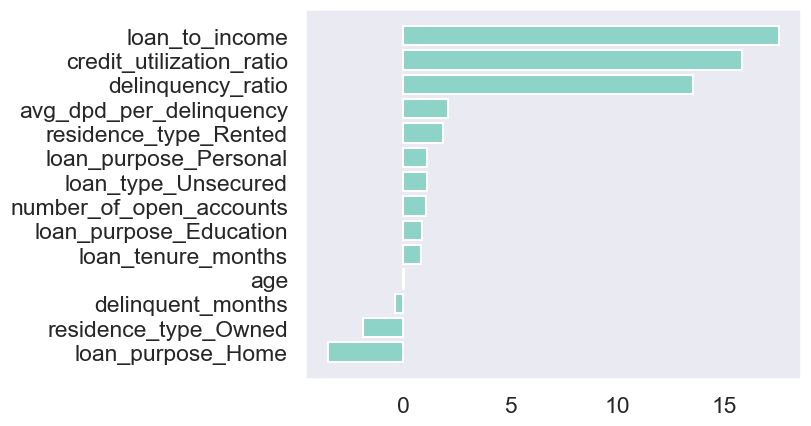

In [149]:
feature_importance=model.coef_[0]
coef_df=pd.DataFrame(feature_importance,index=x_train_balanced.columns,columns=['Coefficient'])
coef_df=coef_df.sort_values(by='Coefficient',ascending=True)
plt.barh(coef_df.index,coef_df['Coefficient'])

In [150]:
gini_coef=2*area-1
print('AUC :',area)
print('GINI :',gini_coef)

AUC : 0.9830905728313202
GINI : 0.9661811456626404


In [151]:
from joblib import dump
model_data={
    'model':model,
    'features':x_train_balanced.columns,
    'scaler': scalar,
    'cols_to_scale':cols_to_scale,
}
dump(model_data,'artifacts/model_data.joblib')


['artifacts/model_data.joblib']